In [1]:
import vtk
import matplotlib.pyplot as plt
import numpy as np
import os
from vtk import vtkXMLUnstructuredGridReader
from vtk.util.numpy_support import vtk_to_numpy

import matplotlib.patches as patches
from scipy.spatial import KDTree
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pygmt

In [2]:
def cartesian_to_spherical(x, y, z):
    """
    Takes an x, y, z and converts it to spherical coordinates. Returns r, theta, phi
    """
    r = np.sqrt(x**2 + y**2 + z**2)
    theta = 90 - np.rad2deg( np.arccos( z / (np.sqrt(x**2 + y**2 + z**2)) ) )
    phi =  np.sign(y) * np.rad2deg(np.arccos( x / np.sqrt(x**2 + y**2) ))
    phi[np.where(phi < 0)] = phi[np.where(phi < 0)] + 360
    phi[np.where(phi == 0)] = 180
    
    return r, phi, theta

def spherical_to_global_cartesian(r, phi, theta):
    """
    Takes spherical coordinates r, theta, and phi and converts to Cartesian coordinates.
    Returns x, y, z
    """
    x = r * np.sin(np.deg2rad(90 - theta)) * np.cos(np.deg2rad(phi))
    y = r * np.sin(np.deg2rad(90 - theta)) * np.sin(np.deg2rad(phi))
    z = r * np.cos(np.deg2rad(90 - theta))
    
    return x, y, z

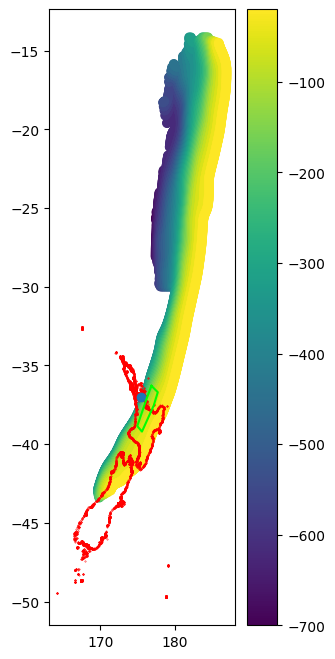

In [3]:
data_dir_path = '../data/'
coast_arr = np.loadtxt(fname=data_dir_path + "coastline.txt")
slab2_cont = np.loadtxt(fname=data_dir_path + "slab2_tonga.in", delimiter='\t', comments='>', dtype=float)
AUS_TVZ = np.loadtxt(fname=data_dir_path + "DEP_zealith2/AUS_lith50.xyd", comments='>') + 1e-7

plt.figure(dpi=100, figsize=(3, 8))
plt.scatter(slab2_cont[:, 0], slab2_cont[:, 1], c=slab2_cont[:, 2])
plt.colorbar()
plt.scatter(coast_arr[:, 0], coast_arr[:, 1], c='r', s=0.1)

lat_value = -37
lon_value = 175.5

plt.scatter(lon_value, lat_value)
plt.plot(AUS_TVZ[:, 0], AUS_TVZ[:, 1], c='lime')

# The cell below takes a LONG time, it loads in 5 of the ASPECT models so that the viscosity profiles may be compared against each other

In [4]:
base_model_path = "/Users/danieldouglas/FINAL_SLABS/plate_model/tar_files/"
dry_path = base_model_path + "dry/final_suite/5e20_10kmweak_dry_NEW/solution/"
dry_solutions = np.sort(os.listdir( dry_path ))

wet_crust_path = base_model_path + "wet/wet_crust/final_suite/5e20_10kmweak_wet_crust_FIX_RIDGE_NEW_WB/solution/"
crust_solutions = np.sort(os.listdir( wet_crust_path ))

wet_slab_path = base_model_path + "wet/wet_slab/final_suite/1e21_10kmweak_wet_slab_NEW/solution/"
slab_solutions = np.sort(os.listdir( wet_slab_path ))

wet_mantle_path = base_model_path + "wet/wet_upper_mantle/final_suite/5e20_10kmweak_wet_mantle_NEW/solution/"
mantle_solutions = np.sort(os.listdir( wet_mantle_path ))

het_slab_path = base_model_path + "wet/wet_variable/final_suite/5e20_variable_hydration_new_CONVERGE_NEW/solution/"
het_slab_solutions = np.sort(os.listdir( het_slab_path ))

path_array = np.array([dry_path, wet_crust_path, 
                       wet_slab_path, wet_mantle_path, 
                       het_slab_path])
solutions_array = np.array([dry_solutions, crust_solutions, 
                            slab_solutions, mantle_solutions,
                            het_slab_solutions], dtype=object)

t_step = 0
dry_viscosities = np.empty(0)
dry_positions = np.empty(0)
upper_mantle = np.empty(0)
slab = np.empty(0)
crust = np.empty(0)

wet_crust_viscosities = np.empty(0)
wet_crust_positions = np.empty(0)

wet_slab_viscosities = np.empty(0)
wet_slab_positions = np.empty(0)

wet_mantle_viscosities = np.empty(0)
wet_mantle_positions = np.empty(0)

het_slab_viscosities = np.empty(0)
het_slab_positions = np.empty(0)

for i in range(len(path_array)):
    for soln in solutions_array[i]:
        if soln[-4:-1] == '.vt' and soln[9:14] == str(t_step).zfill(5):

            file_path = os.path.join(path_array[i], soln)
            reader = vtkXMLUnstructuredGridReader()
            reader.SetFileName(file_path)
            reader.Update()
            data = reader.GetOutput()
            points = data.GetPoints()
            x = vtk_to_numpy(points.GetData())
            viscosity = vtk_to_numpy(data.GetPointData().GetArray('viscosity'))
            
            if i == 0:
                if len(dry_positions) == 0:
                    dry_positions = x
                else:
                    dry_positions = np.concatenate( (dry_positions, x), axis=0)

                dry_viscosities = np.concatenate( (dry_viscosities, viscosity) )
                upper_mantle = np.concatenate( (upper_mantle, vtk_to_numpy(data.GetPointData().GetArray('Upper_Mantle'))) )
                crust = np.concatenate( (crust, vtk_to_numpy(data.GetPointData().GetArray('Crust'))) )
                slab = np.concatenate( (slab, vtk_to_numpy(data.GetPointData().GetArray('Base_Subducting'))) )
                
            if i == 1:
                if len(wet_crust_positions) == 0:
                    wet_crust_positions = x
                else:
                    wet_crust_positions = np.concatenate( (wet_crust_positions, x), axis=0)

                wet_crust_viscosities = np.concatenate( (wet_crust_viscosities, viscosity) )
                
            if i == 2:
                if len(wet_slab_positions) == 0:
                    wet_slab_positions = x
                else:
                    wet_slab_positions = np.concatenate( (wet_slab_positions, x), axis=0)

                wet_slab_viscosities = np.concatenate( (wet_slab_viscosities, viscosity) )
                
            if i == 3:
                if len(wet_mantle_positions) == 0:
                    wet_mantle_positions = x
                else:
                    wet_mantle_positions = np.concatenate( (wet_mantle_positions, x), axis=0)

                wet_mantle_viscosities = np.concatenate( (wet_mantle_viscosities, viscosity) )

            if i == 4:
                if len(het_slab_positions) == 0:
                    het_slab_positions = x
                else:
                    het_slab_positions = np.concatenate( (het_slab_positions, x), axis=0)

                het_slab_viscosities = np.concatenate( (het_slab_viscosities, viscosity) )
    print("Model " + str(i+1) + " loaded\n")        

Model 1 loaded

Model 2 loaded

Model 3 loaded

Model 4 loaded

Model 5 loaded



In [5]:
UM_indices = np.where(upper_mantle >= 0.99)
UM_X = dry_positions[:, 0][UM_indices]
UM_Y = dry_positions[:, 1][UM_indices]
UM_Z = dry_positions[:, 2][UM_indices]

crust_indices = np.where(crust >= 0.99)
crust_X = dry_positions[:, 0][crust_indices]
crust_Y = dry_positions[:, 1][crust_indices]
crust_Z = dry_positions[:, 2][crust_indices]

slab_indices  = np.where(slab >= 0.99)
slab_X = dry_positions[:, 0][slab_indices]
slab_Y = dry_positions[:, 1][slab_indices]
slab_Z = dry_positions[:, 2][slab_indices]

In [6]:
dry_ASPECT_r, dry_ASPECT_phi, dry_ASPECT_theta = cartesian_to_spherical(dry_positions[:, 0], dry_positions[:, 1], dry_positions[:, 2])
crust_ASPECT_r, crust_ASPECT_phi, crust_ASPECT_theta = cartesian_to_spherical(wet_crust_positions[:, 0], wet_crust_positions[:, 1], wet_crust_positions[:, 2])
slab_ASPECT_r, slab_ASPECT_phi, slab_ASPECT_theta = cartesian_to_spherical(wet_slab_positions[:, 0], wet_slab_positions[:, 1], wet_slab_positions[:, 2])
mantle_ASPECT_r, mantle_ASPECT_phi, mantle_ASPECT_theta = cartesian_to_spherical(wet_mantle_positions[:, 0], wet_mantle_positions[:, 1], wet_mantle_positions[:, 2])
het_ASPECT_r, het_ASPECT_phi, het_ASPECT_theta = cartesian_to_spherical(het_slab_positions[:, 0], het_slab_positions[:, 1], het_slab_positions[:, 2])

UM_r, UM_phi, UM_theta = cartesian_to_spherical(UM_X, UM_Y, UM_Z)
crust_r, crust_phi, crust_theta = cartesian_to_spherical(crust_X, crust_Y, crust_Z)
slab_r, slab_phi, slab_theta = cartesian_to_spherical(slab_X, slab_Y, slab_Z)

radius_array = np.linspace(np.max(dry_ASPECT_r), np.min(dry_ASPECT_r), 1601)
dlat = 0.01
dlon = 0.01
lat_bounds = np.array([lat_value + dlat, lat_value - dlat])
lon_bounds = np.array([lon_value + dlon, lon_value - dlon])

dry_depth_profile_indices = np.where( (dry_ASPECT_phi <= np.max(lon_bounds)) & (dry_ASPECT_phi >= np.min(lon_bounds)) & \
                                      (dry_ASPECT_theta <= np.max(lat_bounds)) & (dry_ASPECT_theta >= np.min(lat_bounds)) )
crust_depth_profile_indices = np.where( (crust_ASPECT_phi <= np.max(lon_bounds)) & (crust_ASPECT_phi >= np.min(lon_bounds)) & \
                                        (crust_ASPECT_theta <= np.max(lat_bounds)) & (crust_ASPECT_theta >= np.min(lat_bounds)) )
slab_depth_profile_indices = np.where( (slab_ASPECT_phi <= np.max(lon_bounds)) & (slab_ASPECT_phi >= np.min(lon_bounds)) & \
                                       (slab_ASPECT_theta <= np.max(lat_bounds)) & (slab_ASPECT_theta >= np.min(lat_bounds)) )
mantle_depth_profile_indices = np.where( (mantle_ASPECT_phi <= np.max(lon_bounds)) & (mantle_ASPECT_phi >= np.min(lon_bounds)) & \
                                         (mantle_ASPECT_theta <= np.max(lat_bounds)) & (mantle_ASPECT_theta >= np.min(lat_bounds)) )
het_depth_profile_indices = np.where( (het_ASPECT_phi <= np.max(lon_bounds)) & (het_ASPECT_phi >= np.min(lon_bounds)) & \
                                       (het_ASPECT_theta <= np.max(lat_bounds)) & (het_ASPECT_theta >= np.min(lat_bounds)) )

UM_profile_indices    = np.where( (UM_phi <= np.max(lon_bounds)) & (UM_phi >= np.min(lon_bounds)) & \
                                  (UM_theta <= np.max(lat_bounds)) & (UM_theta >= np.min(lat_bounds)) )
crust_profile_indices = np.where( (crust_phi <= np.max(lon_bounds)) & (crust_phi >= np.min(lon_bounds)) & \
                                  (crust_theta <= np.max(lat_bounds)) & (crust_theta >= np.min(lat_bounds)) )
slab_profile_indices  = np.where( (slab_phi <= np.max(lon_bounds)) & (slab_phi >= np.min(lon_bounds)) & \
                                  (slab_theta <= np.max(lat_bounds)) & (slab_theta >= np.min(lat_bounds)) )

dry_depth_profile_r     = dry_ASPECT_r[dry_depth_profile_indices]
dry_depth_profile_phi   = dry_ASPECT_phi[dry_depth_profile_indices]
dry_depth_profile_theta = dry_ASPECT_theta[dry_depth_profile_indices]
dry_visc_ASPECT_profile = dry_viscosities[dry_depth_profile_indices]

crust_depth_profile_r     = crust_ASPECT_r[crust_depth_profile_indices]
crust_depth_profile_phi   = crust_ASPECT_phi[crust_depth_profile_indices]
crust_depth_profile_theta = crust_ASPECT_theta[crust_depth_profile_indices]
crust_visc_ASPECT_profile = wet_crust_viscosities[crust_depth_profile_indices]

slab_depth_profile_r     = slab_ASPECT_r[slab_depth_profile_indices]
slab_depth_profile_phi   = slab_ASPECT_phi[slab_depth_profile_indices]
slab_depth_profile_theta = slab_ASPECT_theta[slab_depth_profile_indices]
slab_visc_ASPECT_profile = wet_slab_viscosities[slab_depth_profile_indices]

het_depth_profile_r     = het_ASPECT_r[het_depth_profile_indices]
het_depth_profile_phi   = het_ASPECT_phi[het_depth_profile_indices]
het_depth_profile_theta = het_ASPECT_theta[het_depth_profile_indices]
het_visc_ASPECT_profile = het_slab_viscosities[het_depth_profile_indices]

mantle_depth_profile_r     = mantle_ASPECT_r[mantle_depth_profile_indices]
mantle_depth_profile_phi   = mantle_ASPECT_phi[mantle_depth_profile_indices]
mantle_depth_profile_theta = mantle_ASPECT_theta[mantle_depth_profile_indices]
mantle_visc_ASPECT_profile = wet_mantle_viscosities[mantle_depth_profile_indices]


UM_depth_profile_r     = UM_r[UM_profile_indices]
UM_depth_profile_phi   = UM_phi[UM_profile_indices]
UM_depth_profile_theta = UM_theta[UM_profile_indices]
UM_ASPECT_profile      = upper_mantle[UM_profile_indices]

CRUST_depth_profile_r     = crust_r[crust_profile_indices]
CRUST_depth_profile_phi   = crust_phi[crust_profile_indices]
CRUST_depth_profile_theta = crust_theta[crust_profile_indices]
CRUST_ASPECT_profile      = crust[crust_profile_indices]

SLAB_depth_profile_r     = slab_r[slab_profile_indices]
SLAB_depth_profile_phi   = slab_phi[slab_profile_indices]
SLAB_depth_profile_theta = slab_theta[slab_profile_indices]
SLAB_ASPECT_profile      = slab[slab_profile_indices]

dry_profile_x, dry_profile_y, dry_profile_z = spherical_to_global_cartesian(dry_depth_profile_r, dry_depth_profile_phi, dry_depth_profile_theta)
dry_KDTREE = KDTree(np.c_[dry_profile_x, dry_profile_y, dry_profile_z])

crust_profile_x, crust_profile_y, crust_profile_z = spherical_to_global_cartesian(crust_depth_profile_r, crust_depth_profile_phi, crust_depth_profile_theta)
crust_KDTREE = KDTree(np.c_[crust_profile_x, crust_profile_y, crust_profile_z])

slab_profile_x, slab_profile_y, slab_profile_z = spherical_to_global_cartesian(slab_depth_profile_r, slab_depth_profile_phi, slab_depth_profile_theta)
slab_KDTREE = KDTree(np.c_[slab_profile_x, slab_profile_y, slab_profile_z])

het_profile_x, het_profile_y, het_profile_z = spherical_to_global_cartesian(het_depth_profile_r, het_depth_profile_phi, het_depth_profile_theta)
het_KDTREE = KDTree(np.c_[het_profile_x, het_profile_y, het_profile_z])

mantle_profile_x, mantle_profile_y, mantle_profile_z = spherical_to_global_cartesian(mantle_depth_profile_r, mantle_depth_profile_phi, mantle_depth_profile_theta)
mantle_KDTREE = KDTree(np.c_[mantle_profile_x, mantle_profile_y, mantle_profile_z])


UM_profile_x, UM_profile_y, UM_profile_z = spherical_to_global_cartesian(UM_depth_profile_r, UM_depth_profile_phi, UM_depth_profile_theta)
UM_KDTREE = KDTree(np.c_[UM_profile_x, UM_profile_y, UM_profile_z])

CRUST_profile_x, CRUST_profile_y, CRUST_profile_z = spherical_to_global_cartesian(CRUST_depth_profile_r, CRUST_depth_profile_phi, CRUST_depth_profile_theta)
CRUST_KDTREE = KDTree(np.c_[CRUST_profile_x, CRUST_profile_y, CRUST_profile_z])

SLAB_profile_x, SLAB_profile_y, SLAB_profile_z = spherical_to_global_cartesian(SLAB_depth_profile_r, SLAB_depth_profile_phi, SLAB_depth_profile_theta)
SLAB_KDTREE = KDTree(np.c_[SLAB_profile_x, SLAB_profile_y, SLAB_profile_z])

dry_visc_profile = np.zeros(len(radius_array))
crust_visc_profile = np.zeros(len(radius_array))
slab_visc_profile = np.zeros(len(radius_array))
het_visc_profile = np.zeros(len(radius_array))
mantle_visc_profile = np.zeros(len(radius_array))

UM_location_profile = np.zeros(len(radius_array))
CRUST_location_profile = np.zeros(len(radius_array))
SLAB_location_profile = np.zeros(len(radius_array))

for i in range(len(radius_array)):
    dry_x_point, dry_y_point, dry_z_point = spherical_to_global_cartesian(radius_array[i], lon_value, lat_value)
    crust_x_point, crust_y_point, crust_z_point = spherical_to_global_cartesian(radius_array[i], lon_value, lat_value)
    slab_x_point, slab_y_point, slab_z_point = spherical_to_global_cartesian(radius_array[i], lon_value, lat_value)
    het_x_point, het_y_point, het_z_point = spherical_to_global_cartesian(radius_array[i], lon_value, lat_value)
    mantle_x_point, mantle_y_point, mantle_z_point = spherical_to_global_cartesian(radius_array[i], lon_value, lat_value)
    UM_x_point, UM_y_point, UM_z_point = spherical_to_global_cartesian(radius_array[i], lon_value, lat_value)
    CRUST_x_point, CRUST_y_point, CRUST_z_point = spherical_to_global_cartesian(radius_array[i], lon_value, lat_value)
    SLAB_x_point, SLAB_y_point, SLAB_z_point = spherical_to_global_cartesian(radius_array[i], lon_value, lat_value)

    
    dd, ii_dry     = dry_KDTREE.query([dry_x_point, dry_y_point, dry_z_point], k=1)
    dd, ii_crust   = crust_KDTREE.query([crust_x_point, crust_y_point, crust_z_point], k=1)
    dd, ii_slab    = slab_KDTREE.query([slab_x_point, slab_y_point, slab_z_point], k=1)
    dd, ii_het     = het_KDTREE.query([het_x_point, het_y_point, het_z_point], k=1)
    dd, ii_mantle  = mantle_KDTREE.query([mantle_x_point, mantle_y_point, mantle_z_point], k=1)

    dd, ii_UM      = UM_KDTREE.query([UM_x_point, UM_y_point, UM_z_point], k=1)
    dd, ii_CRUST   = CRUST_KDTREE.query([CRUST_x_point, CRUST_y_point, CRUST_z_point], k=1)
    dd, ii_SLAB    = SLAB_KDTREE.query([SLAB_x_point, SLAB_y_point, SLAB_z_point], k=1)
    
    dry_visc_profile[i]    = dry_visc_ASPECT_profile[ii_dry]
    crust_visc_profile[i]  = crust_visc_ASPECT_profile[ii_crust]
    slab_visc_profile[i]   = slab_visc_ASPECT_profile[ii_slab]
    het_visc_profile[i]    = np.average(het_visc_ASPECT_profile[ii_het])
    mantle_visc_profile[i] = mantle_visc_ASPECT_profile[ii_mantle]

    UM_location_profile[i]    = UM_ASPECT_profile[ii_UM]
    CRUST_location_profile[i] = CRUST_location_profile[ii_CRUST]
    SLAB_location_profile[i]  = SLAB_location_profile[ii_SLAB]

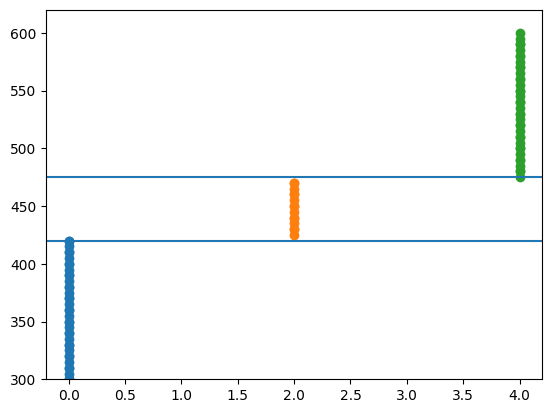

In [7]:
y_bounds = np.array([300, 620])
depth_vals = (6371e3 - UM_depth_profile_r) / 1e3

prof_idx = np.where( (depth_vals >= np.min(y_bounds)) & (depth_vals <= np.max(y_bounds)) )

plt.scatter(UM_ASPECT_profile, depth_vals)
plt.scatter(CRUST_ASPECT_profile + 2, (6371e3 - CRUST_depth_profile_r) / 1e3)
plt.scatter(SLAB_ASPECT_profile + 4, (6371e3 - SLAB_depth_profile_r) / 1e3)
plt.ylim(np.min(y_bounds), np.max(y_bounds))

min_slab_depth = np.min((6371e3 - SLAB_depth_profile_r) / 1e3)
max_slab_depth = np.max((6371e3 - SLAB_depth_profile_r) / 1e3)

min_mantle_depth = np.min((6371e3 - UM_depth_profile_r) / 1e3)
max_mantle_depth = np.max((6371e3 - UM_depth_profile_r[prof_idx]) / 1e3)

min_crust_depth = np.copy(max_mantle_depth)
max_crust_depth = np.copy(min_slab_depth)

min_visc_point = 15
max_visc_point = 30

plt.axhline(max_crust_depth)
plt.axhline(min_crust_depth)

# ORIGINAL PLOT

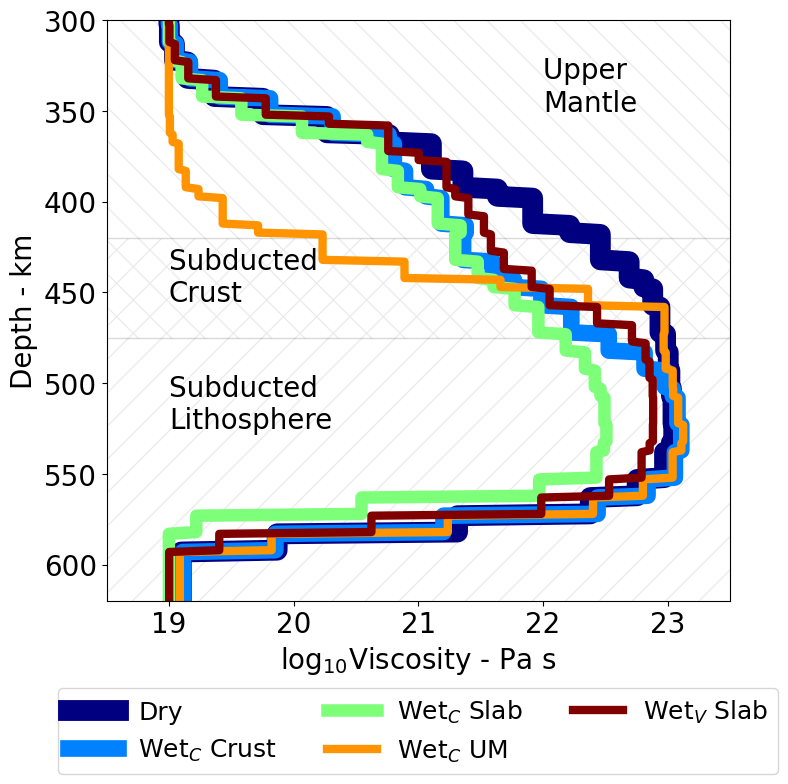

In [8]:
from matplotlib import cm

cm_subsection = np.linspace(0., 1, 5)
colors = [ cm.jet(x) for x in cm_subsection ]

depth_vals = (6371e3 - radius_array) / 1e3
plt.figure(dpi=100, figsize=(8, 8))
plt.plot(np.log10(dry_visc_profile),    depth_vals, lw=15, label='Dry',           c=colors[0])
plt.plot(np.log10(crust_visc_profile),  depth_vals, lw=12, label='Wet$_C$ Crust', c=colors[1])
plt.plot(np.log10(slab_visc_profile),   depth_vals, lw=9,  label='Wet$_C$ Slab',  c=colors[2])
plt.plot(np.log10(mantle_visc_profile), depth_vals, lw=6,  label='Wet$_C$ UM',    c=colors[3], ls='-')
plt.plot(np.log10(het_visc_profile),    depth_vals, lw=6,  label='Wet$_V$ Slab',  c=colors[4], ls='-')

transparency_val = 0.075
UM_rect = patches.Rectangle((min_visc_point, min_mantle_depth), 
                            (max_visc_point - min_visc_point), (max_mantle_depth - min_mantle_depth), 
                             facecolor='none', edgecolor='black', hatch='\\',
                            lw=1, alpha=transparency_val)
plt.gca().add_patch(UM_rect)

CRUST_rect = patches.Rectangle((min_visc_point, min_crust_depth), 
                               (max_visc_point - min_visc_point), (max_crust_depth - min_crust_depth), 
                                facecolor='none', edgecolor='black', hatch='x',
                               lw=1, alpha=transparency_val)
plt.gca().add_patch(CRUST_rect)

SLAB_rect = patches.Rectangle((min_visc_point, min_slab_depth), 
                              (max_visc_point - min_visc_point), (max_slab_depth - min_slab_depth + 50), 
                               facecolor='none', edgecolor='black', hatch='/',
                               lw=1, alpha=transparency_val)
plt.gca().add_patch(SLAB_rect)

plt.text(22, 350, "Upper \nMantle", fontsize=20)
plt.text(19, 455, "Subducted \nCrust", fontsize=20)
plt.text(19, 525, "Subducted \nLithosphere", fontsize=20)

plt.legend(fontsize=18, ncol=3, 
           loc="upper center",
           bbox_to_anchor=(0.5, -0.15), 
           borderaxespad=0)

plt.ylim(300, 620)
# plt.ylim(0, 200)
plt.xlim(18.5, 23.5)
plt.gca().invert_yaxis()
plt.ylabel('Depth - km', fontsize=20)
plt.xlabel('log$_{10}$Viscosity - Pa s', fontsize=20)
plt.xticks([19, 20, 21, 22, 23])
plt.tick_params(labelsize=20)
plt.tight_layout()
plt.savefig('depth_viscosity.png')
plt.show()